# Alpha101 因子批量回测绩效统计

- 回测区间：`2024-01-01` ~ `2026-09-01`（信号窗口）
- 调仓周期：1 天；分组数：5
- 费率：0.0005；滑点：0.001；含资金费：True
- 因子全部转换为 `factor_common` 契约格式（`TYPE`/`META`/`SETTING`/`calc_factor`），截面去极值与秩归一化由框架 `mad_rank` 完成
- 数据源：`data/crypto_quant.h5`（point-in-time top50 宇宙）
- 每个因子的完整 HTML 报告见 `reports/<factor>.html`

> 注意：受 H5 资金费覆盖限制，`all_costs` 场景在真实数据上通常无法完整认证（status=incomplete），此时以 `trading_net`（含手续费+滑点）作为净绩效参考。

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

RESULTS_PATH = Path('../outputs/alpha101_results.json')
payload = json.loads(RESULTS_PATH.read_text())
rows = payload['results']
df = pd.DataFrame(rows)
print(f"factors: {len(df)}, params: {payload['params']}")
df[['factor', 'status', 'static_scan', 'cutoff']].value_counts(['status']).to_frame('count')

factors: 56, params: {'start': '2024-01-01', 'end': '2026-09-01', 'rebalance_days': 1, 'n_groups': 5, 'fee_rate': 0.0005, 'slippage': 0.001, 'include_funding': True}


,count
status,
complete,56


## 1. 总览：IC 指标（全样本 full）

按 `rank_ic_mean` 降序。`icir` 未年化；`t_stat`/`p_value` 为 IC 序列显著性。
`static_scan`/`cutoff` 为未来函数检查结论（静态扫描 + 截断重放一致性）。

In [2]:
ic_cols = ['factor', 'status', 'full.rank_ic_mean', 'full.ic_mean', 'full.icir',
           'full.t_stat', 'full.p_value', 'static_scan', 'cutoff']
ic_table = (df[ic_cols]
            .sort_values('full.rank_ic_mean', ascending=False, na_position='last')
            .reset_index(drop=True))
ic_table.index += 1
ic_table.style.format({c: '{:.4f}' for c in ic_cols if c.startswith('full.')},
                      na_rep='-')

,factor,status,full.rank_ic_mean,full.ic_mean,full.icir,full.t_stat,full.p_value,static_scan,cutoff
1,Alpha50_Factor,complete,0.0287,0.0077,0.0502,1.5679,0.1172,clean,verified
2,Alpha40_Factor,complete,0.0264,-0.0001,-0.0007,-0.0211,0.9832,clean,verified
3,Alpha26_Factor,complete,0.0250,0.0073,0.0449,1.4012,0.1615,clean,verified
4,Alpha55_Factor,complete,0.0244,0.0068,0.0435,1.3589,0.1745,clean,verified
5,Alpha13_Factor,complete,0.0240,-0.0037,-0.0192,-0.5977,0.5502,clean,verified
6,Alpha15_Factor,complete,0.0229,0.0022,0.0112,0.3505,0.7261,clean,verified
7,Alpha8_Factor,complete,0.0224,0.0081,0.0357,1.1131,0.2659,clean,verified
8,Alpha2_Factor,complete,0.0218,0.0068,0.0453,1.4148,0.1575,clean,verified
9,Alpha27_Factor,complete,0.0218,0.0100,0.0635,1.9818,0.0478,clean,verified
10,Alpha19_Factor,complete,0.0195,0.0092,0.0448,1.3973,0.1626,clean,verified


## 2. RankIC 分布图

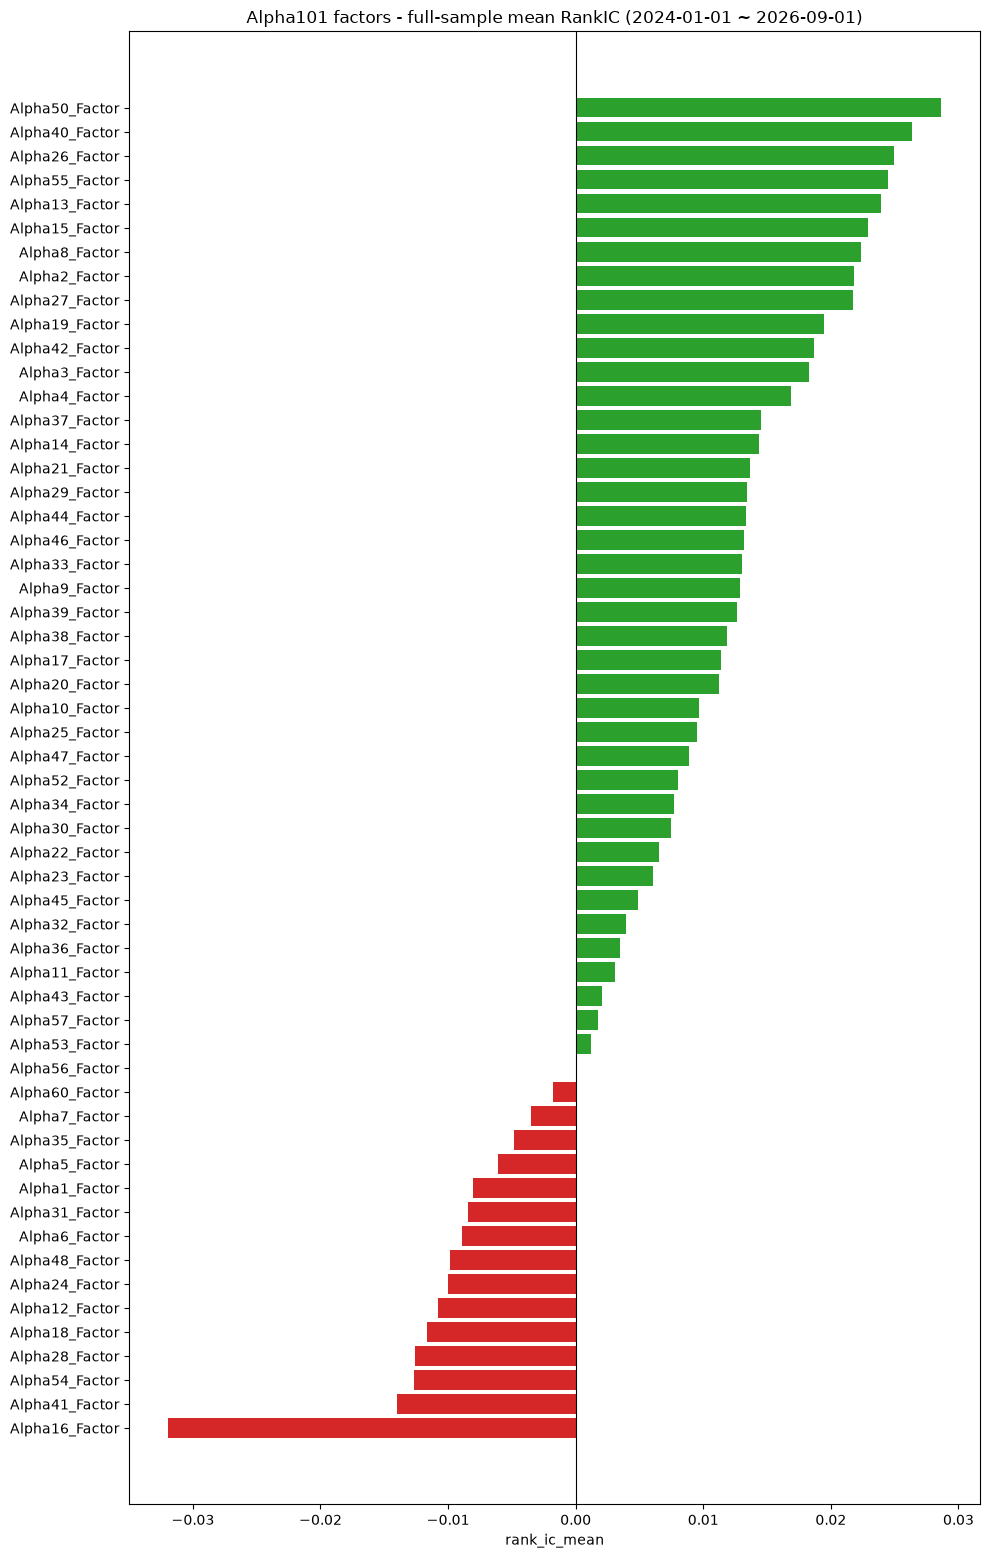

In [3]:
plot_df = df.dropna(subset=['full.rank_ic_mean']).sort_values('full.rank_ic_mean')
fig, ax = plt.subplots(figsize=(10, max(8, 0.28 * len(plot_df))))
colors = ['#d62728' if v < 0 else '#2ca02c' for v in plot_df['full.rank_ic_mean']]
ax.barh(plot_df['factor'], plot_df['full.rank_ic_mean'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Alpha101 factors - full-sample mean RankIC (2024-01-01 ~ 2026-09-01)')
ax.set_xlabel('rank_ic_mean')
plt.tight_layout()
plt.show()

## 3. 样本内 / 样本外 IC 稳定性

样本外 = 最后 180 天。`rank_ic_oos` 与全样本符号一致且幅度未大幅衰减的因子更稳健。

In [4]:
split_cols = ['factor', 'full.rank_ic_mean', 'in_sample.rank_ic_mean',
              'out_of_sample.rank_ic_mean', 'in_sample.t_stat', 'out_of_sample.t_stat']
split_table = (df[split_cols]
               .sort_values('full.rank_ic_mean', ascending=False, na_position='last')
               .reset_index(drop=True))
split_table.index += 1
split_table.style.format({c: '{:.4f}' for c in split_cols if c != 'factor'}, na_rep='-')

,factor,full.rank_ic_mean,in_sample.rank_ic_mean,out_of_sample.rank_ic_mean,in_sample.t_stat,out_of_sample.t_stat
1,Alpha50_Factor,0.0287,0.0278,0.0322,1.4138,0.6750
2,Alpha40_Factor,0.0264,0.0262,0.0269,0.3884,-0.9539
3,Alpha26_Factor,0.0250,0.0248,0.0263,1.5869,-0.0007
4,Alpha55_Factor,0.0244,0.0262,0.0171,1.9468,-0.9141
5,Alpha13_Factor,0.0240,0.0232,0.0273,-0.3609,-0.6305
6,Alpha15_Factor,0.0229,0.0231,0.0221,0.1698,0.4416
7,Alpha8_Factor,0.0224,0.0304,-0.0136,1.7212,-1.2819
8,Alpha2_Factor,0.0218,0.0234,0.0140,1.9983,-0.9742
9,Alpha27_Factor,0.0218,0.0216,0.0229,1.6472,1.1662
10,Alpha19_Factor,0.0195,0.0219,0.0102,1.5332,0.0712


## 4. 多空组合绩效（trading_net = 含手续费+滑点）

`gross` 为无成本对照。收益为复利累计；`max_drawdown` 为复合 NAV 上的最大回撤（小数）。

In [3]:
perf_cols = ['factor', 'trading_net.sharpe', 'trading_net.total_return',
             'trading_net.annual_return', 'trading_net.max_drawdown',
             'trading_net.win_rate', 'gross.sharpe', 'gross.total_return']
perf_table = (df[perf_cols]
              .sort_values('trading_net.sharpe', ascending=False, na_position='last')
              .reset_index(drop=True))
perf_table.index += 1
perf_table.style.format({c: '{:.3f}' for c in perf_cols if c != 'factor'}, na_rep='-')

,factor,trading_net.sharpe,trading_net.total_return,trading_net.annual_return,trading_net.max_drawdown,trading_net.win_rate,gross.sharpe,gross.total_return
1,Alpha32_Factor,0.759,0.389,0.131,0.198,0.495,1.599,1.102
2,Alpha41_Factor,0.036,-0.062,-0.023,0.315,0.522,0.878,0.670
3,Alpha27_Factor,0.009,-0.034,-0.013,0.296,0.514,0.600,0.265
4,Alpha50_Factor,-0.734,-0.309,-0.129,0.395,0.483,0.231,0.068
5,Alpha19_Factor,-0.788,-0.426,-0.187,0.546,0.461,1.106,0.842
6,Alpha26_Factor,-1.121,-0.456,-0.204,0.467,0.472,-0.005,-0.048
7,Alpha6_Factor,-1.170,-0.497,-0.227,0.544,0.480,-0.083,-0.095
8,Alpha11_Factor,-1.188,-0.522,-0.242,0.592,0.451,1.102,0.763
9,Alpha16_Factor,-1.213,-0.492,-0.224,0.552,0.463,-0.760,-0.358
10,Alpha3_Factor,-1.231,-0.457,-0.204,0.465,0.486,-0.105,-0.085


## 5. 净 Sharpe 分布图

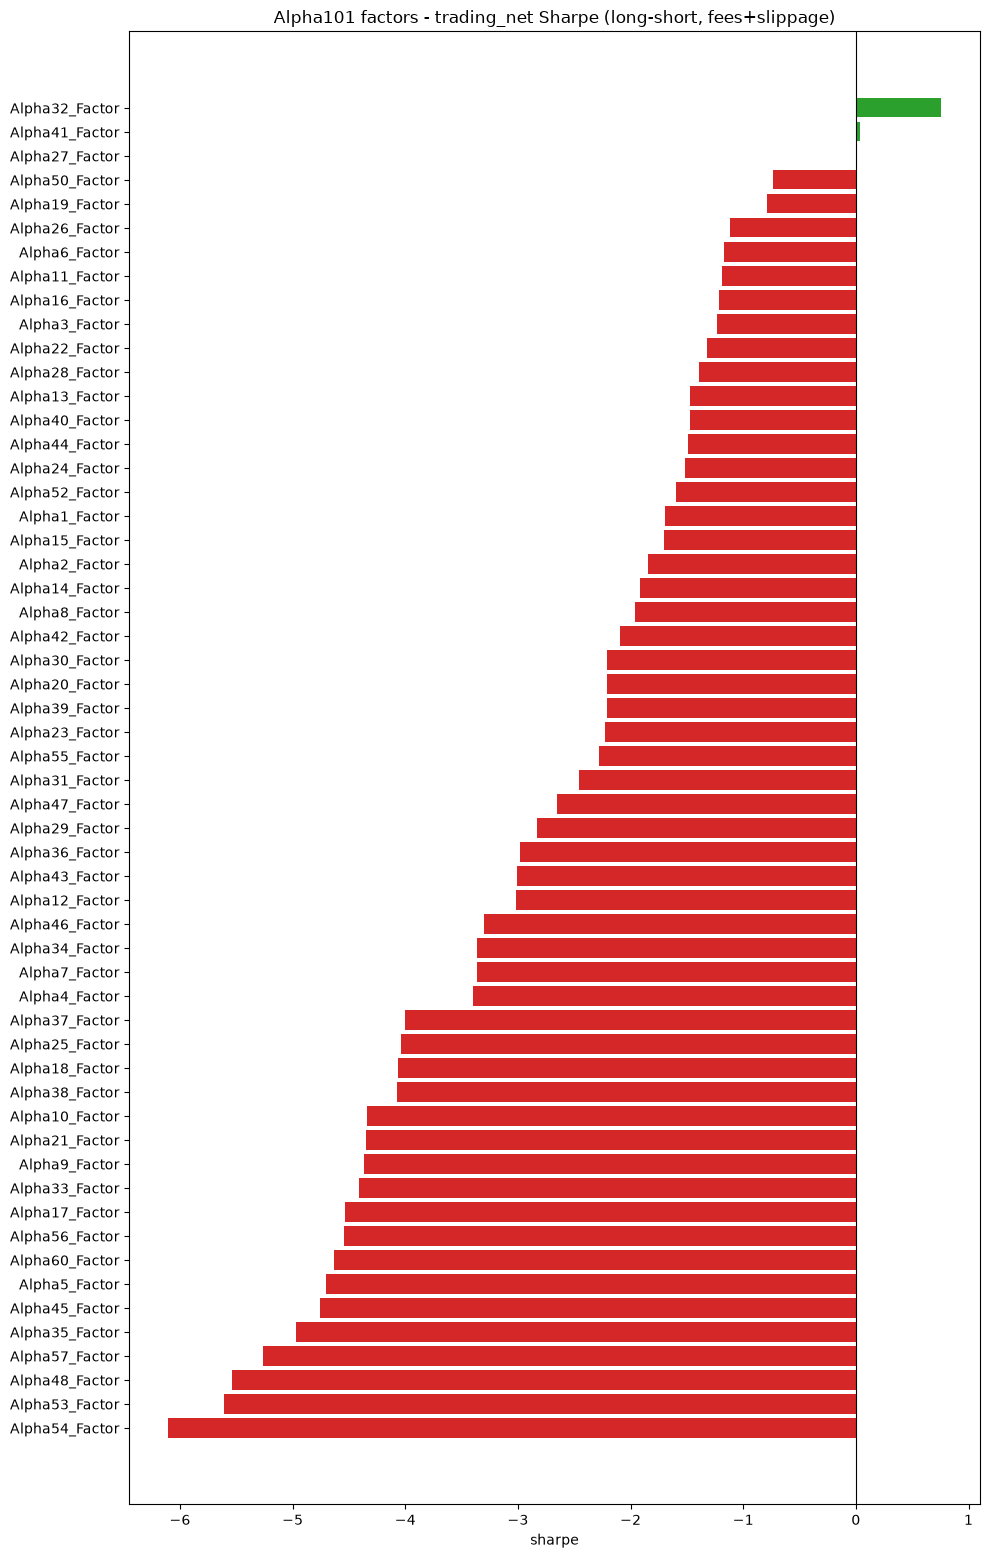

In [6]:
plot_df = df.dropna(subset=['trading_net.sharpe']).sort_values('trading_net.sharpe')
fig, ax = plt.subplots(figsize=(10, max(8, 0.28 * len(plot_df))))
colors = ['#d62728' if v < 0 else '#2ca02c' for v in plot_df['trading_net.sharpe']]
ax.barh(plot_df['factor'], plot_df['trading_net.sharpe'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Alpha101 factors - trading_net Sharpe (long-short, fees+slippage)')
ax.set_xlabel('sharpe')
plt.tight_layout()
plt.show()

## 6. 筛选：可进一步研究的因子

标准：全样本 `|rank_ic_mean| >= 0.02` 且 `|t_stat| >= 2`，且样本外 rank_ic 与全样本同号。
按 `|rank_ic_mean|` 降序。

In [4]:
mask = ((df['full.rank_ic_mean'].abs() >= 0.02)
        & (df['full.t_stat'].abs() >= 2)
        & (df['out_of_sample.rank_ic_mean'] * df['full.rank_ic_mean'] > 0))
selected = (df.loc[mask, ['factor', 'full.rank_ic_mean', 'full.t_stat',
                          'in_sample.rank_ic_mean', 'out_of_sample.rank_ic_mean',
                          'trading_net.sharpe', 'trading_net.total_return',
                          'trading_net.max_drawdown']]
            .assign(abs_rank_ic=lambda x: x['full.rank_ic_mean'].abs())
            .sort_values('abs_rank_ic', ascending=False)
            .drop(columns='abs_rank_ic')
            .reset_index(drop=True))
selected.index += 1
print(f'selected: {len(selected)} / {len(df)}')
selected.style.format({c: '{:.4f}' for c in selected.columns if c != 'factor'}, na_rep='-')

selected: 1 / 56


,factor,full.rank_ic_mean,full.t_stat,in_sample.rank_ic_mean,out_of_sample.rank_ic_mean,trading_net.sharpe,trading_net.total_return,trading_net.max_drawdown
1,Alpha16_Factor,-0.0319,-3.6028,-0.0342,-0.0214,-1.2130,-0.4921,0.5518


## 7. 失败 / 异常因子

评估未到达 complete/incomplete 状态的因子及错误信息。

In [8]:
bad = df[~df['status'].isin(['complete', 'incomplete'])]
if bad.empty:
    print('无失败因子')
else:
    display(bad[['factor', 'status', 'error']].reset_index(drop=True))

无失败因子
